In [152]:
#Osnovne biblioteke

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter
from collections import Counter
from scipy.stats import randint
from pathlib import Path


In [2]:
#Scikit-learn – pipeline i transformacije

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    QuantileTransformer,
    FunctionTransformer,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
#Scikit-learn – modeli

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor
)
from sklearn.neural_network import MLPRegressor

In [4]:
#Scikit-learn – evaluacija, metrika i 

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_squared_log_error,
    make_scorer
)
from sklearn.inspection import permutation_importance

In [5]:
#Boosting modeli

import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [154]:
current_directory = str(Path.cwd())
print(current_directory)

C:\Users\aleks\Sberbank\Sberbank-House-Pricing


In [155]:
data = pd.read_csv(current_directory+"/train.csv")
df = pd.DataFrame(data)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [156]:
df.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_av

In [157]:
print(df.dtypes.unique())

[dtype('int64') dtype('O') dtype('float64')]


In [158]:
df.drop(columns=['id'], inplace=True)

In [159]:
df.shape

(30471, 291)

In [160]:
# prag za periferiju (npr. stanovi dalje od 30 km od Kremlja)
df = df[df["kremlin_km"] <= 30].copy()

In [161]:
target = df["price_doc"]
print(target.isna().sum())

0


In [162]:
print(df["price_doc"].head())
print(df["price_doc"].min(), df["price_doc"].max())

0     5850000
1     6000000
2     5700000
3    13100000
4    16331452
Name: price_doc, dtype: int64
100000 111111112


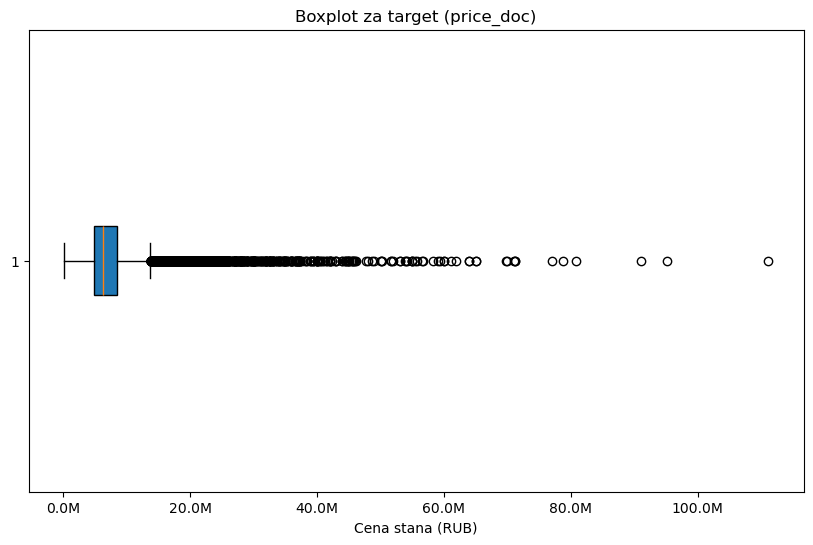

In [163]:

plt.figure(figsize=(10,6))
plt.boxplot(df["price_doc"], vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

In [164]:
df = df.sample(n=10000, random_state=42)

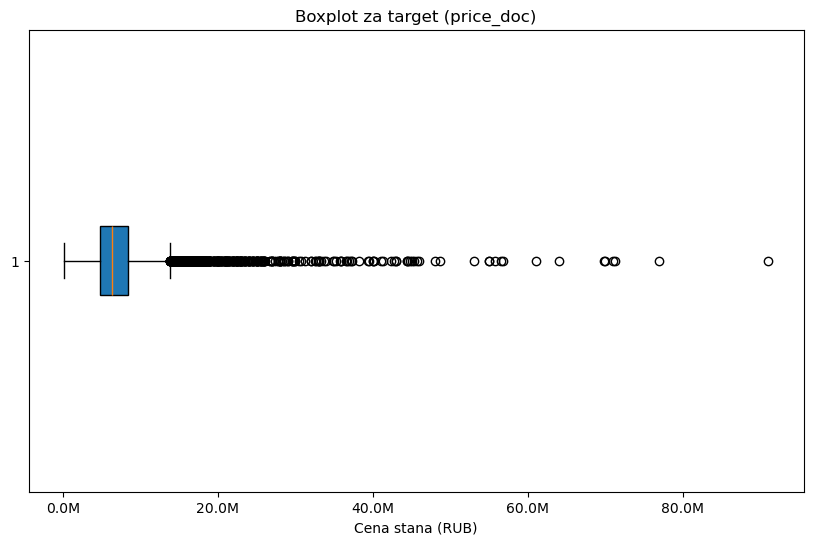

In [165]:
plt.figure(figsize=(10,6))
plt.boxplot(df["price_doc"], vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

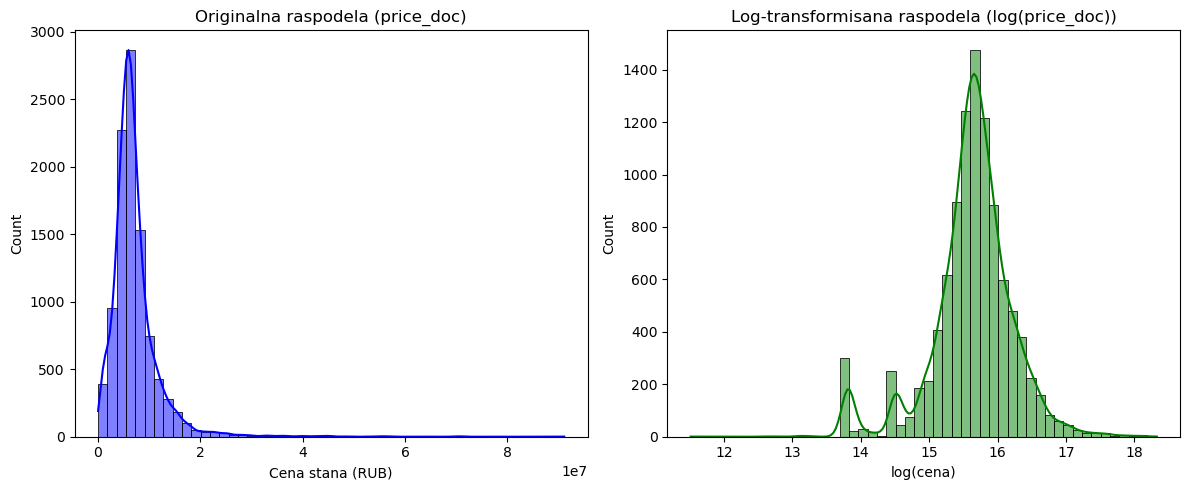

In [166]:
# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["price_doc"], kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(df["price_doc"]), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()

In [167]:
new_cols = []

In [168]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
start = df["timestamp"].min()

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month

df.drop(columns=['timestamp'], inplace=True)
new_cols.extend(["year","month"])

In [169]:
df.shape

(10000, 292)

In [170]:
df["floor_ratio"] = df.apply(
    lambda row: row["floor"] / row["max_floor"] if pd.notnull(row["max_floor"]) and row["max_floor"] > 0 else 0,
    axis=1
)

In [171]:
df["build_age"] = df["year"] - df["build_year"]
new_cols.extend(["floor_ratio","build_age"])

In [172]:
df.shape

(10000, 294)

In [173]:
cols = [c for c in df.columns if c != 'price_doc'] + ['price_doc']
df = df[cols]

In [174]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [175]:
print(y.name)

price_doc


In [176]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [177]:
y_train.head()

10907    5073100
5427     3180200
7500     4000000
29721    5113544
11861    5425062
Name: price_doc, dtype: int64

In [178]:
"""Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_train = X_train.loc[mask]
y_train = y_train.loc[mask]"""

lower = y_train.quantile(0.005)
upper = y_train.quantile(0.9)

mask = (y_train >= lower) & (y_train <= upper)

X_train_clean = X_train.loc[mask]
y_train_clean = y_train.loc[mask]

In [179]:
print(y_train.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0


In [180]:
df = df.dropna(subset=["price_doc"]).copy()

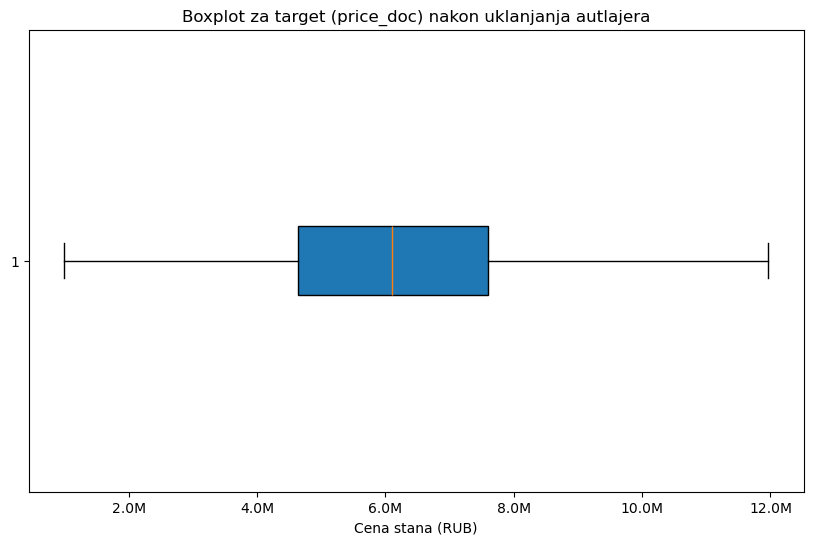

In [181]:
plt.figure(figsize=(10,6))
plt.boxplot(y_train_clean, vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc) nakon uklanjanja autlajera")
plt.xlabel("Cena stana (RUB)")
plt.show()

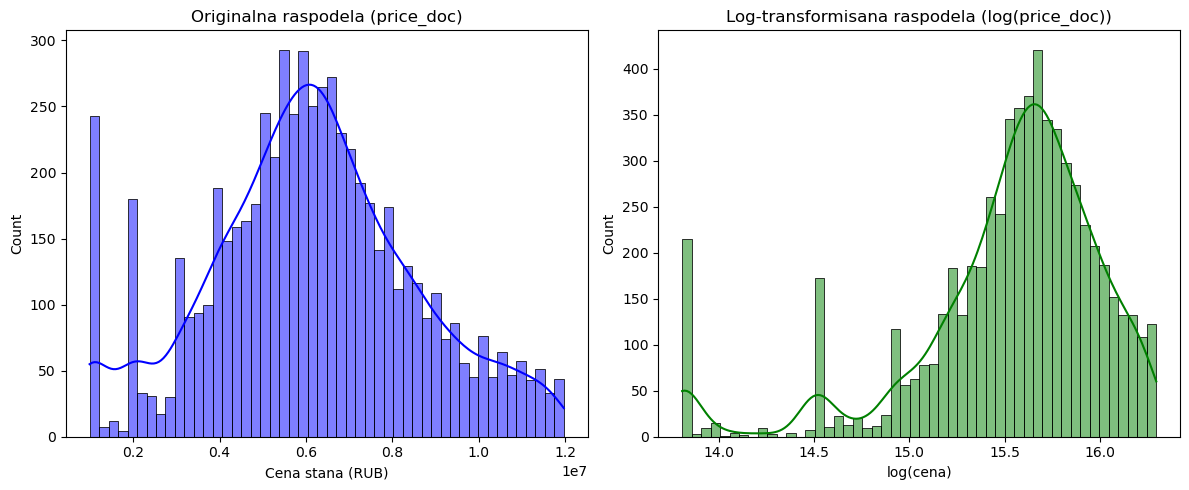

In [182]:
# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y_train_clean, kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(y_train_clean), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()

In [183]:
df["price_doc_log"] = np.log1p(df["price_doc"])

In [184]:
y_train_clean = np.log1p(y_train_clean)

### Test

In [186]:
def missing_values_ratio(df, ratio_for_na_values=0.3, target_col="price_doc", corr_threshold=0.4):
    # 1. Missing ratio for each column
    missing_ratio = df.isnull().mean().sort_values(ascending=False)
    
    # 2. Select only columns with > threshold % missing
    cols_over_n = missing_ratio[missing_ratio > ratio_for_na_values]
    cols_to_drop = []
    
    if not cols_over_n.empty:
        print(f"Kolone sa preko {round(ratio_for_na_values*100)}% nedostajućih vrednosti:\n")
        
        # 3. For each such column, compute correlation with target
        for col in cols_over_n.index:
            if df[col].dtype in ['int64', 'float64']:  # only numeric can correlate
                corr_val = df[[col, target_col]].corr().iloc[0, 1]  # correlation col <-> target
                if (corr_val is None) or (abs(corr_val) < corr_threshold):
                    cols_to_drop.append(col)
                print(f"{col}: {cols_over_n[col]*100:.2f}% NaN, korelacija sa targetom = {corr_val:.3f}")
        return cols_to_drop
    else:
        print("Nema takvih kolona")
        return []

In [187]:
columns_to_drop = missing_values_ratio(df, 0.3, "price_doc", 0.4)

Kolone sa preko 30% nedostajućih vrednosti:

hospital_beds_raion: 46.40% NaN, korelacija sa targetom = 0.134
build_year: 44.68% NaN, korelacija sa targetom = 0.003
build_age: 44.68% NaN, korelacija sa targetom = -0.003
state: 44.56% NaN, korelacija sa targetom = 0.128
cafe_sum_500_min_price_avg: 41.95% NaN, korelacija sa targetom = 0.040
cafe_avg_price_500: 41.95% NaN, korelacija sa targetom = 0.040
cafe_sum_500_max_price_avg: 41.95% NaN, korelacija sa targetom = 0.040
max_floor: 31.84% NaN, korelacija sa targetom = 0.072
material: 31.84% NaN, korelacija sa targetom = 0.058
num_room: 31.84% NaN, korelacija sa targetom = 0.492
kitch_sq: 31.84% NaN, korelacija sa targetom = 0.022


In [188]:
print(columns_to_drop)

['hospital_beds_raion', 'build_year', 'build_age', 'state', 'cafe_sum_500_min_price_avg', 'cafe_avg_price_500', 'cafe_sum_500_max_price_avg', 'max_floor', 'material', 'kitch_sq']


In [189]:
X_test = X_test.drop(columns=columns_to_drop)  
X_train = X_train_clean.drop(columns=columns_to_drop) 

In [190]:
X_train.shape, X_test.shape

((6293, 283), (3000, 283))

In [191]:
train_imputer = SimpleImputer

In [192]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [193]:
train_num = X_train[num_cols].copy()
train_cat = X_train[cat_cols].copy()

In [194]:
train_num.shape, train_cat.shape

((6293, 266), (6293, 15))

In [195]:
for cat in cat_cols:
    print(cat)
    print(train_cat[cat].unique())

product_type
['OwnerOccupier' 'Investment']
sub_area
['Nekrasovka' 'Poselenie Shherbinka' 'Otradnoe' 'Poselenie Desjonovskoe'
 'Poselenie Moskovskij' 'Perovo' 'Hovrino' 'Dmitrovskoe' 'Mitino'
 'Rjazanskij' 'Lefortovo' 'Tverskoe' 'Severnoe Tushino' 'Jaroslavskoe'
 "Kon'kovo" 'Poselenie Sosenskoe' "Gol'janovo" "Mar'ino"
 'Vostochnoe Izmajlovo' 'Teplyj Stan' 'Butyrskoe' 'Zjablikovo'
 'Poselenie Filimonkovskoe' 'Begovoe' 'Juzhnoe Butovo'
 'Poselenie Voskresenskoe' 'Koptevo' 'Fili Davydkovo' 'Krylatskoe'
 'Ochakovo-Matveevskoe' 'Troparevo-Nikulino' 'Ivanovskoe' 'Kuncevo'
 'Orehovo-Borisovo Juzhnoe' 'Poselenie Vnukovskoe' 'Nagatino-Sadovniki'
 'Zapadnoe Degunino' 'Strogino' 'Juzhnoe Medvedkovo' 'Obruchevskoe'
 'Jasenevo' 'Severnoe Medvedkovo' 'Shhukino' "Altuf'evskoe"
 'Novo-Peredelkino' 'Juzhnoportovoe' 'Dorogomilovo' "Tekstil'shhiki"
 'Timirjazevskoe' 'Orehovo-Borisovo Severnoe' 'Alekseevskoe'
 'Chertanovo Juzhnoe' 'Presnenskoe' 'Birjulevo Zapadnoe' 'Izmajlovo'
 'Nagatinskij Zaton' 'Golovi

In [196]:
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]
nominal_cols = [col for col in cat_cols if col not in ordinal_cols + freq_cols]

In [197]:
print(nominal_cols)

['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']


In [198]:
train_cat["ecology"] = train_cat["ecology"].replace("no data", np.nan)
train_cat = train_cat.replace(["nan", "NaN", ""], np.nan)
imputer = SimpleImputer(strategy="most_frequent").set_output(transform="pandas")
train_cat = imputer.fit_transform(train_cat)

In [199]:
train_cat.isna().sum().sum()

0

In [200]:
imputer_num = SimpleImputer(strategy="median").set_output(transform="pandas")
train_num = imputer.fit_transform(train_num)

train_num.isna().sum().sum()

0

In [201]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X

In [202]:
def categorical_to_numeric(df_obj, nominal_cols, ordinal_cols, freq_cols):
    if freq_cols:
        fe = FrequencyEncoder(columns=freq_cols, normalize=True)
        df_obj[freq_cols] = fe.fit_transform(df_obj[freq_cols])


    if nominal_cols:
        ohe = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
        df_encoded = pd.DataFrame(
            ohe.fit_transform(df_obj[nominal_cols]),
            columns=ohe.get_feature_names_out(nominal_cols),
            index=df_obj.index
        )
        df_obj = df_obj.drop(columns=nominal_cols)
        df_obj = pd.concat([df_obj, df_encoded], axis=1)

    if ordinal_cols:
        order = [["excellent", "good", "satisfactory", "poor"]]
        enc = OrdinalEncoder(categories=order)
        for col in ordinal_cols:
            df_obj[col] = enc.fit_transform(df_obj[[col]])

    return df_obj

In [203]:
train_cat_to_num = categorical_to_numeric(train_cat, nominal_cols, ordinal_cols, freq_cols)

In [204]:
train_cat_to_num.shape

(6293, 15)

In [205]:
train_cat_with_target = train_cat_to_num.copy()
train_cat_with_target['price_doc'] = y_train 

corr = train_cat_with_target.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr >= 0.25) | (corr <= -0.25)])

price_doc    1.0
Name: price_doc, dtype: float64


In [206]:
def columns_selector(train_num_with_target, corr_treshold = 0.25):
    
    corr_matrix = train_num_with_target.corr(numeric_only=True)
    target_corr = corr_matrix["price_doc"].drop("price_doc")
    selected_features = target_corr[target_corr.abs() > corr_treshold].index.tolist()
    
    print(f"Feature-i sa korelacijom > {corr_treshold} sa targetom:")
    print(selected_features)

    return selected_features

Feature-i sa korelacijom > 0.11 sa targetom:
['sub_area', 'ecology', 'product_type_OwnerOccupier']


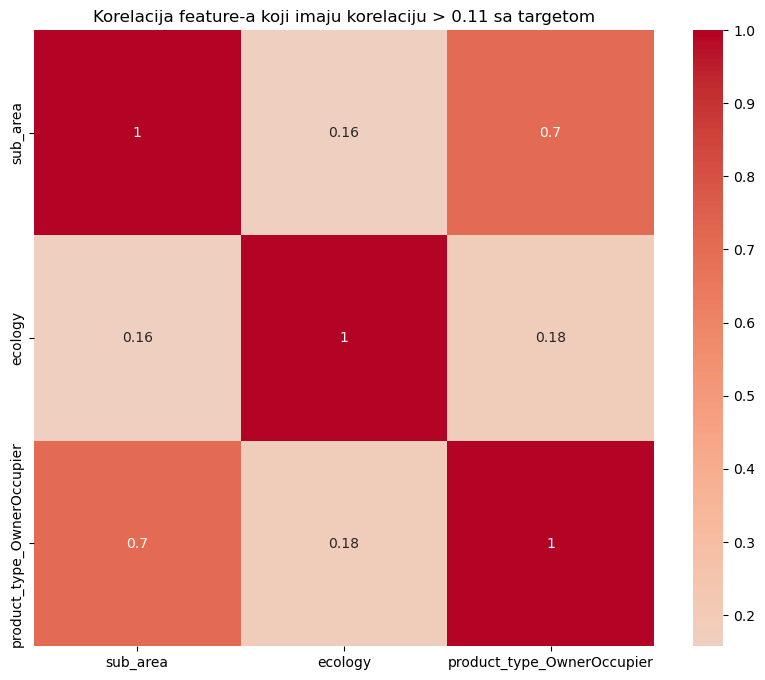

In [207]:
corr_treshold = 0.11
selected_features = columns_selector(train_cat_with_target, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(train_cat_with_target[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [208]:
train_cat_to_num.head()

,sub_area,ecology,product_type_OwnerOccupier,culture_objects_top_25_yes,thermal_power_plant_raion_yes,incineration_raion_yes,oil_chemistry_raion_yes,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes
10907,0.062768,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5427,0.017321,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7500,0.011600,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29721,0.011282,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11861,0.034642,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [209]:
train_num_with_target = train_num.copy()
train_num_with_target['price_doc'] = y_train 

corr = train_num_with_target.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr >= 0.2) | (corr <= -0.2)])

price_doc               1.000000
full_sq                 0.337736
num_room                0.314478
life_sq                 0.226803
work_male               0.203822
raion_popul             0.200956
market_shop_km         -0.201173
park_km                -0.201256
kremlin_km             -0.202175
bulvar_ring_km         -0.203269
exhibition_km          -0.207275
sadovoe_km             -0.210953
fitness_km             -0.212027
preschool_km           -0.213285
zd_vokzaly_avto_km     -0.213905
school_km              -0.214302
ttk_km                 -0.217748
shopping_centers_km    -0.218086
basketball_km          -0.218553
nuclear_reactor_km     -0.219518
workplaces_km          -0.221505
ts_km                  -0.221607
metro_min_avto         -0.241780
big_church_km          -0.245158
swim_pool_km           -0.246684
metro_km_avto          -0.248900
metro_km_walk          -0.252875
metro_min_walk         -0.252875
public_healthcare_km   -0.253170
Name: price_doc, dtype: float64


Feature-i sa korelacijom > 0.22 sa targetom:
['full_sq', 'life_sq', 'num_room', 'metro_min_avto', 'metro_km_avto', 'metro_min_walk', 'metro_km_walk', 'ts_km', 'swim_pool_km', 'public_healthcare_km', 'workplaces_km', 'big_church_km']


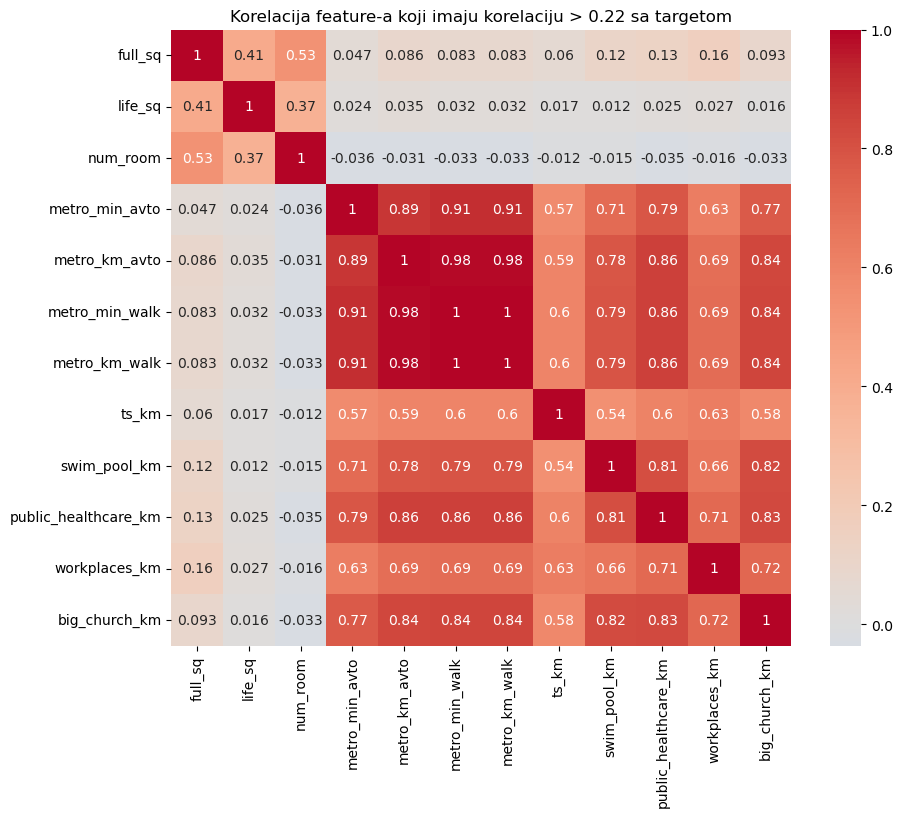

In [210]:
corr_treshold = 0.22

selected_features = columns_selector(train_num_with_target, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(train_num_with_target[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [211]:
def drop_hight_corr_pairs(train_num_with_target, selected_features, pairs_treshold=0.85):

    corr_matrix = train_num_with_target[selected_features].corr()
    
    df_cleared = train_num_with_target[selected_features]
    
    target_corr = df_cleared.corrwith(y_train).abs()
    
    high_corr_pairs = [
        (col1, col2)
        for col1 in corr_matrix.columns
        for col2 in corr_matrix.columns
        if col1 < col2 and corr_matrix.loc[col1, col2] > pairs_treshold
    ]
    
    print(high_corr_pairs)
    print(f"len: {len(high_corr_pairs)}")
    print()
    print("col1 to col2 ratio")
    print()
    cols_to_drop = []
    
    for c1, c2 in high_corr_pairs:
        if target_corr.get(c1, 0) < target_corr.get(c2, 0):
            print(f"{c1} < {c2}  :  {target_corr.get(c1, 0)} < {target_corr.get(c2, 0)}")
            cols_to_drop.append(c2)
        else:
            print(f"{c2} < {c1}  :  {target_corr.get(c2, 0)} < {target_corr.get(c1, 0)}")       
            cols_to_drop.append(c1)
    
    df_cleared = df_cleared.drop(columns=cols_to_drop)
    print()
    print("columns to keep :")
    print(df_cleared.columns)
    print(f"len: {len(df_cleared.columns)}")

    return df_cleared

In [212]:
df_cleared = drop_hight_corr_pairs(train_num_with_target, selected_features, pairs_treshold=0.9)
df_cleared.head()

[('metro_min_avto', 'metro_min_walk'), ('metro_km_avto', 'metro_min_walk'), ('metro_km_avto', 'metro_km_walk'), ('metro_km_walk', 'metro_min_avto'), ('metro_km_walk', 'metro_min_walk')]
len: 5

col1 to col2 ratio

metro_min_avto < metro_min_walk  :  0.24177974435319227 < 0.25287503117590154
metro_km_avto < metro_min_walk  :  0.24890024578581188 < 0.25287503117590154
metro_km_avto < metro_km_walk  :  0.24890024578581188 < 0.25287503116886284
metro_min_avto < metro_km_walk  :  0.24177974435319227 < 0.25287503116886284
metro_km_walk < metro_min_walk  :  0.25287503116886284 < 0.25287503117590154

columns to keep :
Index(['full_sq', 'life_sq', 'num_room', 'metro_min_avto', 'metro_km_avto',
       'ts_km', 'swim_pool_km', 'public_healthcare_km', 'workplaces_km',
       'big_church_km'],
      dtype='object')
len: 10


,full_sq,life_sq,num_room,metro_min_avto,metro_km_avto,ts_km,swim_pool_km,public_healthcare_km,workplaces_km,big_church_km
10907,52.0,52.0,2.0,4.721045,3.776836,5.013100,8.106936,5.422551,5.599071,3.468289
5427,40.0,19.0,2.0,9.643206,7.278816,12.921262,5.713733,8.156060,11.133493,5.181165
7500,40.0,21.0,2.0,1.460105,0.747751,0.657723,1.184762,1.969965,2.523853,0.255579
29721,68.0,30.0,2.0,15.839451,12.718568,13.011139,15.850078,12.478079,13.611344,9.559846
11861,62.0,19.0,2.0,8.458554,6.732362,6.009804,6.507849,6.039067,9.907037,4.471586


### 1. Dimenzije i sobe

full_sq → ukupna kvadratura stana (m²).

life_sq → stambena površina stana (m²), dakle samo sobe, bez hodnika, balkona i pomoćnih prostorija.

num_room → broj soba u stanu.

In [214]:
flags = []

In [215]:
def bar_plot(df, col, y_label="price_doc"):
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    plt.title(f"Distribucija {col}")
    plt.xlabel(col)
    plt.ylabel(y_label)
    plt.show()

def scatter_plot(df, col, target = "price_doc"):
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df[target], alpha=0.3)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

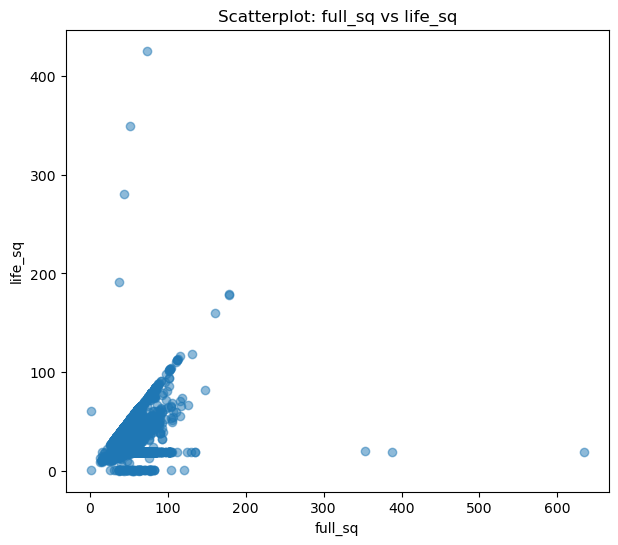

In [216]:
plt.figure(figsize=(7, 6))
plt.scatter(train_num_with_target["full_sq"], train_num_with_target["life_sq"], alpha=0.5)
plt.xlabel("full_sq")
plt.ylabel("life_sq")
plt.title("Scatterplot: full_sq vs life_sq")
plt.show()


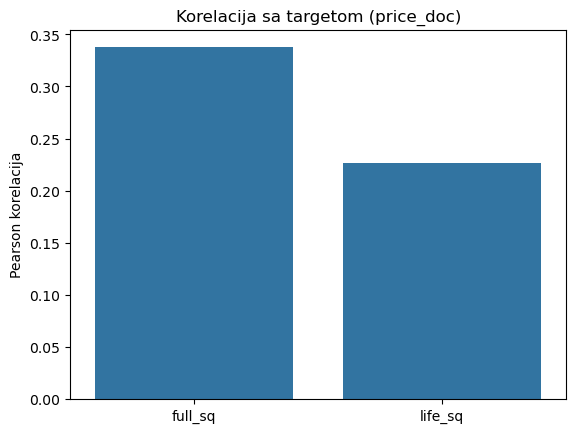

Korelacija full_sq sa targetom: 0.3377357322894416
Korelacija life_sq sa targetom: 0.226803436458226


In [217]:
import matplotlib.pyplot as plt
import seaborn as sns

# Izračunaj korelaciju sa targetom
corr_full = train_num_with_target["full_sq"].corr(train_num_with_target["price_doc"])
corr_life = train_num_with_target["life_sq"].corr(train_num_with_target["price_doc"])

# Ubaci u dict pa u DataFrame za lakši plot
corr_dict = {
    "full_sq": corr_full,
    "life_sq": corr_life
}

sns.barplot(x=list(corr_dict.keys()), y=list(corr_dict.values()))
plt.title("Korelacija sa targetom (price_doc)")
plt.ylabel("Pearson korelacija")
plt.show()

print("Korelacija full_sq sa targetom:", corr_full)
print("Korelacija life_sq sa targetom:", corr_life)

* Solidna korelacija full_sq i life_sq sa targetom

* Loša međusobna korelacija

* Treba zadržati oba

In [219]:
bad_full = df[df["full_sq"] <= 0]
bad_life = df[df["life_sq"] <= 0]
bad_ratio = df[df["life_sq"] > df["full_sq"]]
bad_room_zero = df[df["num_room"] == 0]
bad_room_high = df[df["num_room"] > 10]
df["sqm_per_room"] = df["full_sq"] / df["num_room"].replace(0, np.nan)
bad_sqm_low = df[df["sqm_per_room"] < 8]
bad_sqm_high = df[df["sqm_per_room"] > 80]


print("Provera dal postoje stanovi sa kvadraturom < 0")
print("Kvadratura <= 0:", bad_full.shape[0])
print("life_sq <= 0:", bad_life.shape[0])
print("life_sq > full_sq:", bad_ratio.shape[0])
print("num_room = 0:", bad_room_zero.shape[0])
print("num_room > 10:", bad_room_high.shape[0])
print("sqm_per_room < 8:", bad_sqm_low.shape[0])
print("sqm_per_room > 80:", bad_sqm_high.shape[0])

Provera dal postoje stanovi sa kvadraturom < 0
Kvadratura <= 0: 0
life_sq <= 0: 14
life_sq > full_sq: 14
num_room = 0: 4
num_room > 10: 1
sqm_per_room < 8: 11
sqm_per_room > 80: 21


In [220]:
# --- life_sq ---
df["life_sq_missing_or_zero"] = (df["life_sq"] <= 0).astype(int)
df["life_sq_bigger_full"] = (df["life_sq"] > df["full_sq"]).astype(int)


df.loc[df["life_sq"] <= 0, "life_sq"] = np.nan
df.loc[df["life_sq"] > df["full_sq"], "life_sq"] = np.nan

# --- num_room ---
df["num_room_zero"] = (df["num_room"] == 0).astype(int)
df["num_room_outlier"] = (df["num_room"] > 10).astype(int)

df.loc[df["num_room"] == 0, "num_room"] = np.nan
df.loc[df["num_room"] > 10, "num_room"] = np.nan

df["sqm_per_room"] = df["full_sq"] / df["num_room"].replace(0, np.nan)

df["sqm_too_small"] = (df["sqm_per_room"] < 8).astype(int)
df["sqm_too_big"] = (df["sqm_per_room"] > 80).astype(int)

df.loc[df["sqm_per_room"] < 8, "num_room"] = np.nan
df.loc[df["sqm_per_room"] > 80, "num_room"] = np.nan


flags.extend(["life_sq_bigger_full","life_sq_bigger_full","num_room_zero","num_room_outlier","sqm_too_small","sqm_too_big"])
new_cols.extend(["sqm_per_room"])

Poredjenje full_sq sa num_room

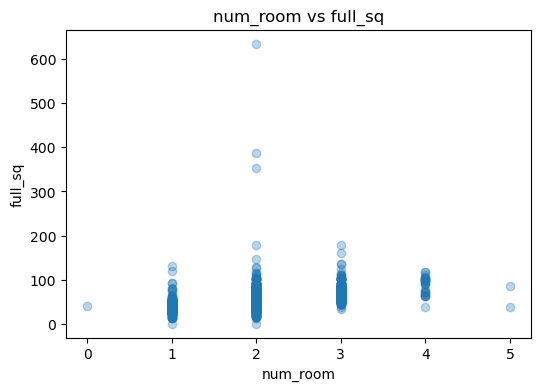

In [222]:
scatter_plot(train_num_with_target, col = "num_room",target="full_sq")

In [223]:
print("full_sq <= 0 :", df[df["full_sq"] <= 0].shape[0])
print("life_sq <= 0 :", df[df["life_sq"] <= 0].shape[0])

print("life_sq > full_sq :", df[df["life_sq"] > df["full_sq"]].shape[0])

print("num_room = 0 :", df[df["num_room"] == 0].shape[0])
print("num_room > 10 :", df[df["num_room"] > 10].shape[0])

print("sqm_per_room < 8 :", df[df["sqm_per_room"] < 8].shape[0])
print("sqm_per_room > 80 :", df[df["sqm_per_room"] > 80].shape[0])

full_sq <= 0 : 0
life_sq <= 0 : 0
life_sq > full_sq : 0
num_room = 0 : 0
num_room > 10 : 0
sqm_per_room < 8 : 10
sqm_per_room > 80 : 21


### 2. Saobraćaj i udaljenosti do centra

* metro_min_avto – vreme u minutima do najbliže metro stanice kolima

* kremlin_km – udaljenost u kilometrima do Kremlja

In [225]:
cols = ["metro_min_avto", "kremlin_km"]

print(df[cols].describe())

       metro_min_avto    kremlin_km
count    10000.000000  10000.000000
mean         3.770472     14.793846
std          3.908874      6.564578
min          0.000000      0.072897
25%          1.683219     10.179723
50%          2.677455     14.294238
75%          4.624288     20.360628
max         34.853238     29.877217


In [226]:
cols = ["metro_min_avto", "kremlin_km"]

thresholds = [0, 1, 2, 5, 10, 20, 50, 100]

for col in cols:
    print(f"\n=== {col} ===")
    for t in thresholds:
        count = (df[col] <= t).sum()
        print(f" <= {t}: {count}")



=== metro_min_avto ===
 <= 0: 1
 <= 1: 741
 <= 2: 3327
 <= 5: 7968
 <= 10: 9621
 <= 20: 9920
 <= 50: 10000
 <= 100: 10000

=== kremlin_km ===
 <= 0: 0
 <= 1: 200
 <= 2: 233
 <= 5: 694
 <= 10: 2411
 <= 20: 7399
 <= 50: 10000
 <= 100: 10000


In [227]:
mask = (df["metro_min_avto"] < 0.5) | (df["kremlin_km"] < 0.1)
df.loc[mask, ["metro_min_avto", "kremlin_km"]] = np.nan
df["is_near_kremlin"] = (df["kremlin_km"] < 1).astype(int)
flags.extend(["is_near_kremlin"])

In [228]:
df.loc[mask, ["metro_min_avto", "kremlin_km"]]

,metro_min_avto,kremlin_km
30119,NaN,NaN
9549,NaN,NaN
28357,NaN,NaN
20908,NaN,NaN
15926,NaN,NaN
...,...,...
27417,NaN,NaN
26641,NaN,NaN
25009,NaN,NaN
11625,NaN,NaN


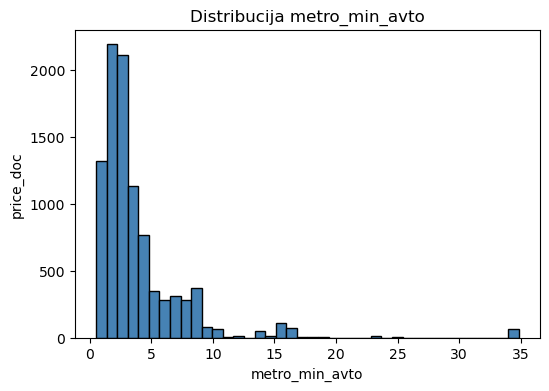

In [229]:
bar_plot(df, col = "metro_min_avto")

In [230]:
df["metro_far"] = (df["metro_min_avto"] > 30).astype(int)
df.loc[df["metro_min_avto"] > 30, "metro_min_avto"] = np.nan
flags.extend(["metro_far"])

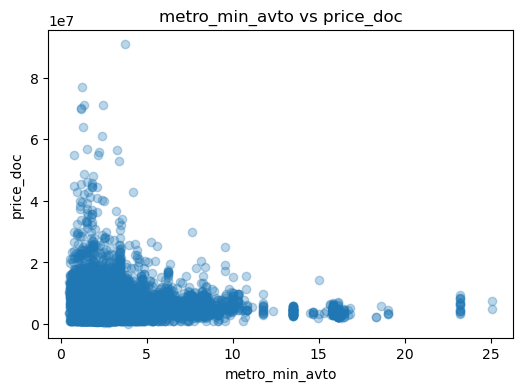

In [231]:
scatter_plot(df, col = "metro_min_avto")

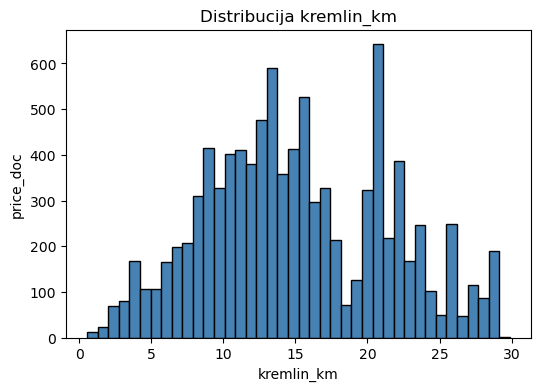

In [232]:
bar_plot(df, col = "kremlin_km")

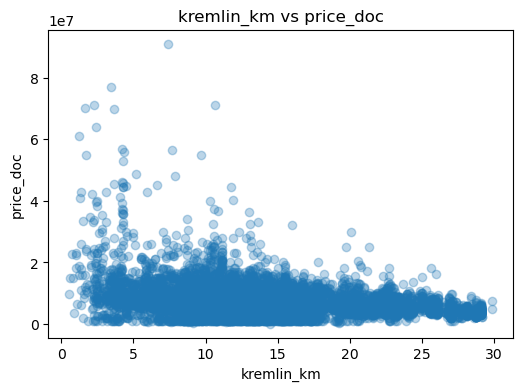

In [233]:
scatter_plot(df, col = "kremlin_km")

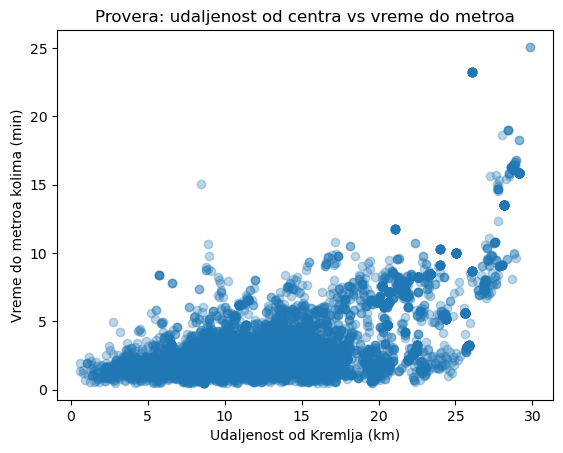

In [234]:
plt.scatter(df["kremlin_km"], df["metro_min_avto"], alpha=0.3)
plt.xlabel("Udaljenost od Kremlja (km)")
plt.ylabel("Vreme do metroa kolima (min)")
plt.title("Provera: udaljenost od centra vs vreme do metroa")
plt.show()

### 3. Okruženje i infrastruktura

* workplaces_km – udaljenost u kilometrima do poslovnih centara

* catering_km – udaljenost u kilometrima do najbližeg restorana ili ketering objekta

* big_church_km – udaljenost u kilometrima do najbliže velike crkve

In [236]:
cols = ["workplaces_km", "catering_km", "big_church_km"]

# pragovi za "previše daleko"
thresholds = {
    "workplaces_km": 50,   # poslovni centri su uglavnom u centru
    "catering_km": 20,     # restorani teško da su preko 20 km daleko
    "big_church_km": 30    # velike crkve obično u gradu
}

for col in cols:
    print(f"\n=== {col} ===")
    print(f"Ukupno vrednosti: {df[col].shape[0]}")
    print(f"=0: {(df[col] == 0).sum()}")
    print(f"> {thresholds[col]} km: {(df[col] > thresholds[col]).sum()}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")
    print()

# dodatne neusaglašenosti sa kremlin_km
print("\n=== Neusaglašenosti u odnosu na kremlin_km ===")
print("workplaces dalje od 2x kremlin:", (df["workplaces_km"] > 2 * df["kremlin_km"]).sum())
print("catering dalje od 10 km i kremlin < 5 km:", ((df["catering_km"] > 10) & (df["kremlin_km"] < 5)).sum())
print("big_church dalje od 20 km i kremlin < 5 km:", ((df["big_church_km"] > 20) & (df["kremlin_km"] < 5)).sum())



=== workplaces_km ===
Ukupno vrednosti: 10000
=0: 3
> 50 km: 0
Min: 0.0, Max: 14.43076725


=== catering_km ===
Ukupno vrednosti: 10000
=0: 0
> 20 km: 0
Min: 0.000503046, Max: 4.117323591


=== big_church_km ===
Ukupno vrednosti: 10000
=0: 0
> 30 km: 0
Min: 0.005222257, Max: 10.17103392


=== Neusaglašenosti u odnosu na kremlin_km ===
workplaces dalje od 2x kremlin: 0
catering dalje od 10 km i kremlin < 5 km: 0
big_church dalje od 20 km i kremlin < 5 km: 0


In [237]:
df["workplaces_zero"] = (df["workplaces_km"] == 0).astype(int)
df["workplaces_far"] = (df["workplaces_km"] > 50).astype(int)
df["big_church_far"] = (df["big_church_km"] > 30).astype(int)

df.loc[df["workplaces_km"] == 0, "workplaces_km"] = np.nan
df.loc[df["workplaces_km"] > 50, "workplaces_km"] = np.nan
df.loc[df["big_church_km"] > 30, "big_church_km"] = np.nan

flags.extend(["workplaces_zero","workplaces_far","big_church_far"])

### 4. Posebne lokacije

* nuclear_reactor_km – udaljenost do nuklearnog reaktora

* detention_facility_km – udaljenost do zatvora / pritvorske jedinice


In [239]:
cols = {
    "nuclear_reactor_km": 100,       # prag za ekstremno daleko
    "detention_facility_km": 60      # prag za ekstremno daleko
}

for col, thr in cols.items():
    print(f"\n=== {col} ===")
    print(f"Ukupno vrednosti: {df[col].shape[0]}")
    print(f"=0: {(df[col] == 0).sum()}")
    print(f"<0.1 km: {(df[col] < 0.1).sum()}")   # praktično "u objektu"
    print(f"> {thr} km: {(df[col] > thr).sum()}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")



=== nuclear_reactor_km ===
Ukupno vrednosti: 10000
=0: 0
<0.1 km: 0
> 100 km: 0
Min: 0.359336246, Max: 23.89407211

=== detention_facility_km ===
Ukupno vrednosti: 10000
=0: 0
<0.1 km: 1
> 60 km: 0
Min: 0.041227084, Max: 38.45431514


In [240]:
df["detention_far"] = (df["detention_facility_km"] > 60).astype(int)
df.loc[df["detention_facility_km"] > 60, "detention_facility_km"] = np.nan
flags.extend(["detention_far"])

In [241]:
df["price_per_m2"] = df["price_doc"] / df["full_sq"]
df = df[df["price_per_m2"].notnull() & (df["price_per_m2"] < 1_000_000)].copy() # ukloni outliere

# Log transformacija
df["log_price_per_m2"] = np.log(df["price_per_m2"])

In [242]:
print(df.shape)

(9990, 310)


In [243]:
df_num = df.select_dtypes("number")

Feature-i sa korelacijom > 0.22 sa targetom:
['full_sq', 'life_sq', 'num_room', 'sport_objects_raion', 'metro_min_walk', 'metro_km_walk', 'ttk_km', 'sadovoe_km', 'bulvar_ring_km', 'kremlin_km', 'zd_vokzaly_avto_km', 'nuclear_reactor_km', 'thermal_power_plant_km', 'swim_pool_km', 'stadium_km', 'basketball_km', 'public_healthcare_km', 'university_km', 'workplaces_km', 'office_km', 'big_church_km', 'theater_km', 'exhibition_km', 'catering_km', 'sport_count_1500', 'office_sqm_2000', 'sport_count_2000', 'office_sqm_3000', 'trc_count_3000', 'trc_sqm_3000', 'sport_count_3000', 'office_count_5000', 'office_sqm_5000', 'trc_count_5000', 'trc_sqm_5000', 'cafe_count_5000', 'cafe_count_5000_na_price', 'cafe_count_5000_price_500', 'cafe_count_5000_price_1000', 'cafe_count_5000_price_1500', 'cafe_count_5000_price_2500', 'cafe_count_5000_price_4000', 'cafe_count_5000_price_high', 'big_church_count_5000', 'church_count_5000', 'leisure_count_5000', 'sport_count_5000', 'price_doc_log', 'price_per_m2', 'l

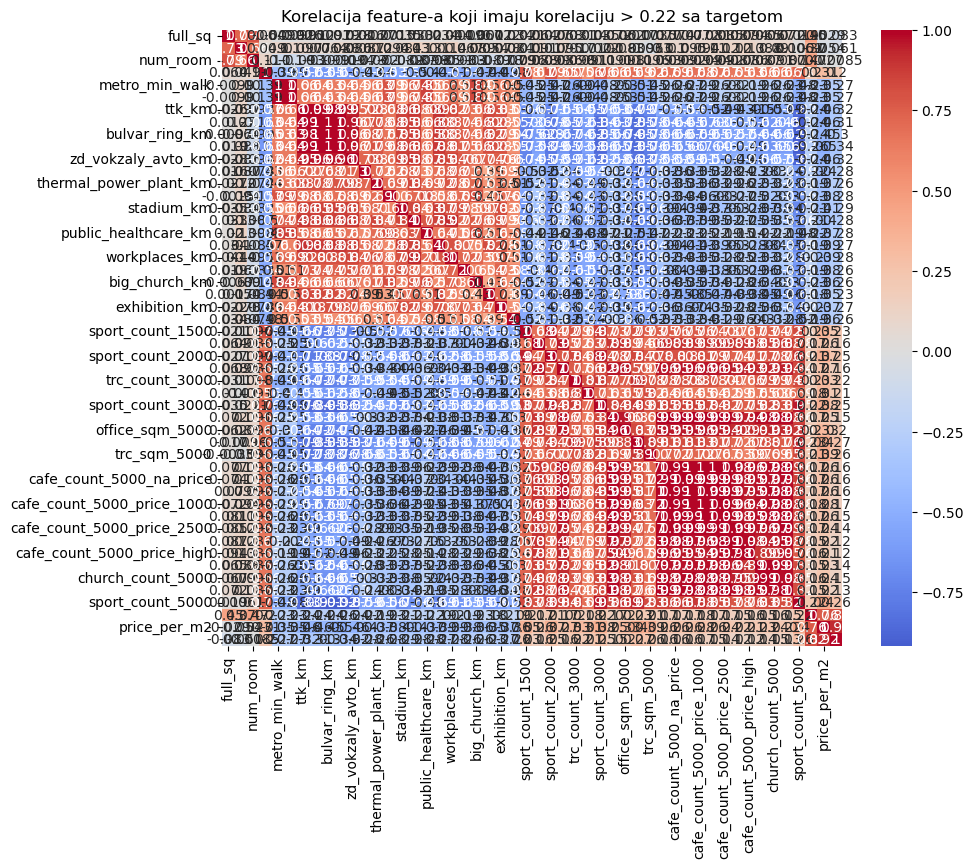

In [244]:
corr_treshold = 0.22
selected_features = columns_selector(df_num, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(df_num[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [245]:
print(flags)

['life_sq_bigger_full', 'life_sq_bigger_full', 'num_room_zero', 'num_room_outlier', 'sqm_too_small', 'sqm_too_big', 'is_near_kremlin', 'metro_far', 'workplaces_zero', 'workplaces_far', 'big_church_far', 'detention_far']


In [246]:
print(new_cols)

['year', 'month', 'floor_ratio', 'build_age', 'sqm_per_room']


In [247]:
df_cleared = drop_hight_corr_pairs(df_num, selected_features, pairs_treshold=0.9)

[('metro_km_walk', 'metro_min_walk'), ('ttk_km', 'zd_vokzaly_avto_km'), ('sadovoe_km', 'ttk_km'), ('sadovoe_km', 'zd_vokzaly_avto_km'), ('bulvar_ring_km', 'ttk_km'), ('bulvar_ring_km', 'sadovoe_km'), ('bulvar_ring_km', 'kremlin_km'), ('bulvar_ring_km', 'zd_vokzaly_avto_km'), ('kremlin_km', 'ttk_km'), ('kremlin_km', 'sadovoe_km'), ('kremlin_km', 'zd_vokzaly_avto_km'), ('basketball_km', 'workplaces_km'), ('sport_count_1500', 'sport_count_2000'), ('office_sqm_2000', 'office_sqm_3000'), ('sport_count_2000', 'sport_count_3000'), ('office_sqm_3000', 'office_sqm_5000'), ('trc_count_3000', 'trc_count_5000'), ('sport_count_3000', 'sport_count_5000'), ('office_count_5000', 'office_sqm_3000'), ('office_count_5000', 'office_sqm_5000'), ('cafe_count_5000', 'office_sqm_3000'), ('cafe_count_5000', 'office_count_5000'), ('cafe_count_5000', 'office_sqm_5000'), ('cafe_count_5000', 'cafe_count_5000_na_price'), ('cafe_count_5000', 'cafe_count_5000_price_500'), ('cafe_count_5000', 'cafe_count_5000_price_10

In [248]:
hight_corr_cols = ['full_sq', 'life_sq', 'num_room', 'sport_objects_raion',
       'metro_min_walk', 'zd_vokzaly_avto_km', 'nuclear_reactor_km',
       'thermal_power_plant_km', 'swim_pool_km', 'stadium_km',
       'public_healthcare_km', 'university_km', 'workplaces_km', 'office_km',
       'big_church_km', 'theater_km', 'exhibition_km', 'catering_km',
       'sport_count_1500', 'office_sqm_2000', 'trc_count_3000', 'trc_sqm_3000',
       'trc_sqm_5000', 'big_church_count_5000']

df_cat = df.select_dtypes("object")
cat_cols = df_cat.columns

In [249]:
def merge_cols(*lists):
    seen = set()
    merged = []
    for lst in lists:
        for col in lst:
            if col not in seen:
                merged.append(col)
                seen.add(col)
    return merged

In [250]:
flags

['life_sq_bigger_full',
 'life_sq_bigger_full',
 'num_room_zero',
 'num_room_outlier',
 'sqm_too_small',
 'sqm_too_big',
 'is_near_kremlin',
 'metro_far',
 'workplaces_zero',
 'workplaces_far',
 'big_church_far',
 'detention_far']

In [486]:
df_hight_corr = df[merge_cols(hight_corr_cols,["price_doc_log","price_doc"])]
df_full = df

df_hybrid1 = df[merge_cols(hight_corr_cols, flags,["price_doc_log","price_doc"])]
df_hybrid2 = df[merge_cols(hight_corr_cols, flags, new_cols,["price_doc_log","price_doc"])]
df_hybrid3 = df[merge_cols(hight_corr_cols, flags, new_cols, cat_cols,["price_doc_log","price_doc"])]

In [252]:
df_hight_corr.dtypes.value_counts()

float64    17
int64       8
Name: count, dtype: int64

In [253]:
df_hybrid1.dtypes.value_counts()

float64    17
int32      11
int64       8
Name: count, dtype: int64

In [254]:
df_hybrid2.dtypes.value_counts()

float64    20
int32      13
int64       8
Name: count, dtype: int64

In [255]:
df_hybrid3.dtypes.value_counts()

float64    20
object     15
int32      13
int64       8
Name: count, dtype: int64

In [256]:
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]
nominal_cols = [col for col in cat_cols if col not in ordinal_cols + freq_cols]
print(nominal_cols)
order = [["excellent", "good", "satisfactory", "poor"]]

['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']


In [257]:
df_hybrid3.loc[:, "ecology"] = df_hybrid3["ecology"].replace("no data", np.nan)
df.loc[:, "ecology"] = df["ecology"].replace("no data", np.nan)

In [258]:
class FrequencyEncoder2(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        # Ako nije DataFrame, napravi ga
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        # Ako nije DataFrame, napravi ga
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns)

In [259]:
hybrid1_cols = list(dict.fromkeys(hight_corr_cols + flags))
hybrid2_cols = list(dict.fromkeys(hight_corr_cols + flags + new_cols))

In [260]:
dupes = [col for col, cnt in Counter(hybrid1_cols).items() if cnt > 1]
print("Duplikati:", dupes)

Duplikati: []


In [261]:
def create_preprocessor(nominal_cols, ordinal_cols, freq_cols, numeric_cols):
    preprocessor = ColumnTransformer(
        transformers=[
            ("nominal", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
             ]), 
             nominal_cols),
            ("ordinal", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("ord", OrdinalEncoder(categories=[["excellent", "good", "satisfactory", "poor"]]))
             ]), 
             ordinal_cols),
            ("freq", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("freq", FrequencyEncoder2(columns=freq_cols))
             ]), 
             freq_cols),
            ("num", 
             Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]),
             numeric_cols)
        ],
        remainder="drop"
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    return pipeline

In [262]:
def create_numeric_preprocessor(cols):

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    
    num_preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, cols)
    ])
    return num_preprocessor

In [490]:
def return_train_test(df_):
    # koristi globalni df za target
    y = df_["price_doc_log"]
  
    
    X = df_.drop(columns=["price_doc","price_doc"])  # sve kolone u df_
    return train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


In [264]:
def evaluate_regression(y_true, y_pred):
    # ako ima negativnih predikcija → postavi na 0 zbog RMSLE
    y_pred_clip = np.maximum(0, y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clip))

    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("R²: ", r2)
    print("RMSLE: ", rmsle)

    results = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "RMSLE": rmsle
    }
    return results

In [265]:

X_train, X_test, y_train, y_test = return_train_test(df_hight_corr)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7992, 25)
X_test shape: (1998, 25)
y_train shape: (7992,)
y_test shape: (1998,)


In [266]:
def unlog(y_log_pred):
    return np.expm1(y_log_pred)


In [267]:
X_train, X_test, y_train, y_test = return_train_test(df_hight_corr)

numeric_preprocessor = create_numeric_preprocessor(df_hight_corr.columns)
pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_test = unlog(y_test)

evaluate_regression(y_test, y_pred)

Broj kolona nakon preprocesiranja: 25
MSE:  1680882031469.082
RMSE:  1296488.3460598795
MAE:  598377.163788873
R²:  0.9264637808485395
RMSLE:  0.13461048107900128


{'MSE': 1680882031469.082,
 'RMSE': 1296488.3460598795,
 'MAE': 598377.163788873,
 'R²': 0.9264637808485395,
 'RMSLE': 0.13461048107900128}

In [268]:


X_train, X_test, y_train, y_test = return_train_test(df_hybrid1)

numeric_preprocessor_hybrid1 = create_numeric_preprocessor(df_hybrid1.columns)


pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid1),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_test = unlog(y_test)

evaluate_regression(y_test, y_pred)

Broj kolona nakon preprocesiranja: 36
MSE:  1662752889298.684
RMSE:  1289477.7583575004
MAE:  595717.5170459149
R²:  0.9272569052598376
RMSLE:  0.13453406255107578


{'MSE': 1662752889298.684,
 'RMSE': 1289477.7583575004,
 'MAE': 595717.5170459149,
 'R²': 0.9272569052598376,
 'RMSLE': 0.13453406255107578}

In [269]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)

numeric_preprocessor_hybrid2 = create_numeric_preprocessor(df_hybrid2.columns)

pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_test = unlog(y_test)

evaluate_regression(y_test, y_pred)

Broj kolona nakon preprocesiranja: 41
MSE:  1526058320619.8247
RMSE:  1235337.330699524
MAE:  574878.4333215737
R²:  0.9332370999260853
RMSLE:  0.13152134468561083


{'MSE': 1526058320619.8247,
 'RMSE': 1235337.330699524,
 'MAE': 574878.4333215737,
 'R²': 0.9332370999260853,
 'RMSLE': 0.13152134468561083}

In [270]:
# isti train/test kao i za linearni model
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)
numeric_preprocessor_hybrid2 = create_numeric_preprocessor(df_hybrid2.columns)
# pipeline sa Ridge umesto LinearRegression
for alpha in [0.1, 1, 10, 100, 1000]:
    ridge_pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", Ridge(alpha=alpha, random_state=42))
    ])

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)

    y_pred = unlog(y_pred)
    y_test_unlog = unlog(y_test)

    print(f"\n=== Ridge alpha={alpha} ===")
    evaluate_regression(y_test_unlog, y_pred)



=== Ridge alpha=0.1 ===
MSE:  1526075289744.5046
RMSE:  1235344.1988953948
MAE:  574850.225937699
R²:  0.9332363575508038
RMSLE:  0.13152143450663806

=== Ridge alpha=1 ===
MSE:  1526228656271.7622
RMSE:  1235406.2717469756
MAE:  574598.0650529437
R²:  0.933229647981454
RMSLE:  0.13152229490569636

=== Ridge alpha=10 ===
MSE:  1527825940667.6423
RMSE:  1236052.5638772983
MAE:  572100.7248473522
R²:  0.9331597690410027
RMSLE:  0.13153600477692373

=== Ridge alpha=100 ===
MSE:  1549860673265.4663
RMSE:  1244934.0035782887
MAE:  549097.8504692926
R²:  0.9321957805546476
RMSLE:  0.13214355673121986

=== Ridge alpha=1000 ===
MSE:  2123774480377.3555
RMSE:  1457317.5633256314
MAE:  478649.58476766
R²:  0.9070878606032734
RMSLE:  0.16066761974691107


In [271]:
numeric_preprocessor_hybrid2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# pipeline sa Ridge
ridge_pipeline_scaled = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", Ridge(alpha=0.1, random_state=42))  # start sa najboljim alpha
])

# treniranje
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)
ridge_pipeline_scaled.fit(X_train, y_train)

print("Broj kolona nakon preprocesiranja:", 
      ridge_pipeline_scaled.named_steps["preprocessor"].transform(X_train).shape[1])

# predikcije
y_pred = ridge_pipeline_scaled.predict(X_test)
y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

# evaluacija
print(evaluate_regression(y_test_unlog, y_pred))

Broj kolona nakon preprocesiranja: 41
MSE:  6785.115870502377
RMSE:  82.37181478213515
MAE:  38.45211692298654
R²:  0.9999999997031608
RMSLE:  9.251629106134001e-06
{'MSE': 6785.115870502377, 'RMSE': 82.37181478213515, 'MAE': 38.45211692298654, 'R²': 0.9999999997031608, 'RMSLE': 9.251629106134001e-06}


In [272]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)

for alpha in [0.0001, 0.001, 0.01, 0.1, 1]:
    lasso_pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", Lasso(alpha=0.001, random_state=42, max_iter=10000))
    ])
    
    # treniranje
    lasso_pipeline.fit(X_train, y_train)
    
    print("Broj kolona nakon preprocesiranja:", 
          lasso_pipeline.named_steps["preprocessor"].transform(X_train).shape[1])
    
    # predikcije
    y_pred = lasso_pipeline.predict(X_test)
    y_pred = unlog(y_pred)
    y_test_unlog = unlog(y_test)
    
    # evaluacija
    print(alpha)
    print()
    print(evaluate_regression(y_test_unlog, y_pred))


Broj kolona nakon preprocesiranja: 41
0.0001

MSE:  228442368.04491577
RMSE:  15114.31004197399
MAE:  5908.184779887535
R²:  0.9999900059684586
RMSLE:  0.0010045632037903123
{'MSE': 228442368.04491577, 'RMSE': 15114.31004197399, 'MAE': 5908.184779887535, 'R²': 0.9999900059684586, 'RMSLE': 0.0010045632037903123}
Broj kolona nakon preprocesiranja: 41
0.001

MSE:  228442368.04491577
RMSE:  15114.31004197399
MAE:  5908.184779887535
R²:  0.9999900059684586
RMSLE:  0.0010045632037903123
{'MSE': 228442368.04491577, 'RMSE': 15114.31004197399, 'MAE': 5908.184779887535, 'R²': 0.9999900059684586, 'RMSLE': 0.0010045632037903123}
Broj kolona nakon preprocesiranja: 41
0.01

MSE:  228442368.04491577
RMSE:  15114.31004197399
MAE:  5908.184779887535
R²:  0.9999900059684586
RMSLE:  0.0010045632037903123
{'MSE': 228442368.04491577, 'RMSE': 15114.31004197399, 'MAE': 5908.184779887535, 'R²': 0.9999900059684586, 'RMSLE': 0.0010045632037903123}
Broj kolona nakon preprocesiranja: 41
0.1

MSE:  228442368.04491

In [273]:
for alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    model = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", lasso)
    ])
    model.fit(X_train, y_train)
    
    coef = model.named_steps["model"].coef_
    nonzero = np.sum(coef != 0)
    
    print(f"alpha={alpha} → broj aktivnih feature-a: {nonzero}")

alpha=0.0001 → broj aktivnih feature-a: 1
alpha=0.001 → broj aktivnih feature-a: 1
alpha=0.01 → broj aktivnih feature-a: 1
alpha=0.1 → broj aktivnih feature-a: 1
alpha=1 → broj aktivnih feature-a: 0
alpha=10 → broj aktivnih feature-a: 0
alpha=100 → broj aktivnih feature-a: 0
alpha=500 → broj aktivnih feature-a: 0
alpha=1000 → broj aktivnih feature-a: 0


In [290]:

results = {}

#kombinacije alpha i l1_ratio
for alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10]:
    for l1_ratio in [0.2, 0.5, 0.7, 0.9]:
        model = Pipeline(steps=[
            ("preprocessor", numeric_preprocessor_hybrid2),
            ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000))
        ])
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_pred = unlog(y_pred)
        y_test_unlog = unlog(y_test)

        metrics = evaluate_regression(y_test_unlog, y_pred)
        
        results[(alpha, l1_ratio)] = metrics
        print(f"alpha={alpha}, l1_ratio={l1_ratio} → {metrics}")


MSE:  12149904.884138135
RMSE:  3485.671367776678
MAE:  2145.8967951940817
R²:  0.9999994684587904
RMSLE:  0.000391120560802628
alpha=0.0001, l1_ratio=0.2 → {'MSE': 12149904.884138135, 'RMSE': 3485.671367776678, 'MAE': 2145.8967951940817, 'R²': 0.9999994684587904, 'RMSLE': 0.000391120560802628}
MSE:  1467517.2492665178
RMSE:  1211.4112634718722
MAE:  473.20985394671203
R²:  0.9999999357981892
RMSLE:  8.04143588982688e-05
alpha=0.0001, l1_ratio=0.5 → {'MSE': 1467517.2492665178, 'RMSE': 1211.4112634718722, 'MAE': 473.20985394671203, 'R²': 0.9999999357981892, 'RMSLE': 8.04143588982688e-05}
MSE:  1774657.846456924
RMSE:  1332.162845322194
MAE:  520.3818289437243
R²:  0.9999999223612211
RMSLE:  8.843090299434852e-05
alpha=0.0001, l1_ratio=0.7 → {'MSE': 1774657.846456924, 'RMSE': 1332.162845322194, 'MAE': 520.3818289437243, 'R²': 0.9999999223612211, 'RMSLE': 8.843090299434852e-05}
MSE:  2110966.697786784
RMSE:  1452.9166176304764
MAE:  567.555231915705
R²:  0.999999907648183
RMSLE:  9.644776

In [292]:
def rmsle(y_true, y_pred):
    # osiguraj da nema negativnih vrednosti
    y_true = np.maximum(0, y_true)
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

In [293]:


# Pipeline: preprocesiranje + ElasticNet
pipe = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", ElasticNet(random_state=42, max_iter=10000))
])

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

# param grid
param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.7, 0.9]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,                # 5-fold cross validation
    scoring=rmsle_scorer,  # možeš i "r2" ili custom RMSLE
    n_jobs=-1            # koristi sve procesore
)

# fit
grid.fit(X_train, y_train)

print("Najbolji parametri:", grid.best_params_)
print("Najbolji score (RMSLE):", grid.best_score_)

best_model = grid.best_estimator_

# predikcija na test setu
y_pred = best_model.predict(X_test)

# vrati iz loga (ako je target bio logovan)
y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

# izračunaj metrike
metrics = evaluate_regression(y_test_unlog, y_pred)

print("Test set performance sa najboljim parametrima:")
for k, v in metrics.items():
    print(f"{k}: {v}")

Najbolji parametri: {'model__alpha': 0.0001, 'model__l1_ratio': 0.5}
Najbolji score (RMSLE): -5.146413985661603e-06
MSE:  1467517.2492665178
RMSE:  1211.4112634718722
MAE:  473.20985394671203
R²:  0.9999999357981892
RMSLE:  8.04143588982688e-05
Test set performance sa najboljim parametrima:
MSE: 1467517.2492665178
RMSE: 1211.4112634718722
MAE: 473.20985394671203
R²: 0.9999999357981892
RMSLE: 8.04143588982688e-05


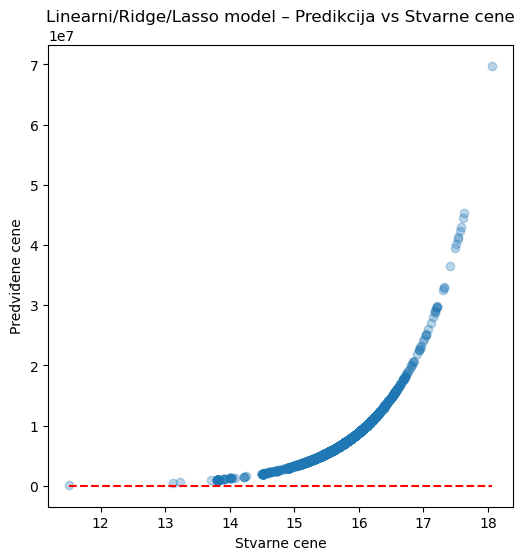

In [294]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")  # idealna linija
plt.xlabel("Stvarne cene")
plt.ylabel("Predviđene cene")
plt.title("Linearni/Ridge/Lasso model – Predikcija vs Stvarne cene")
plt.show()

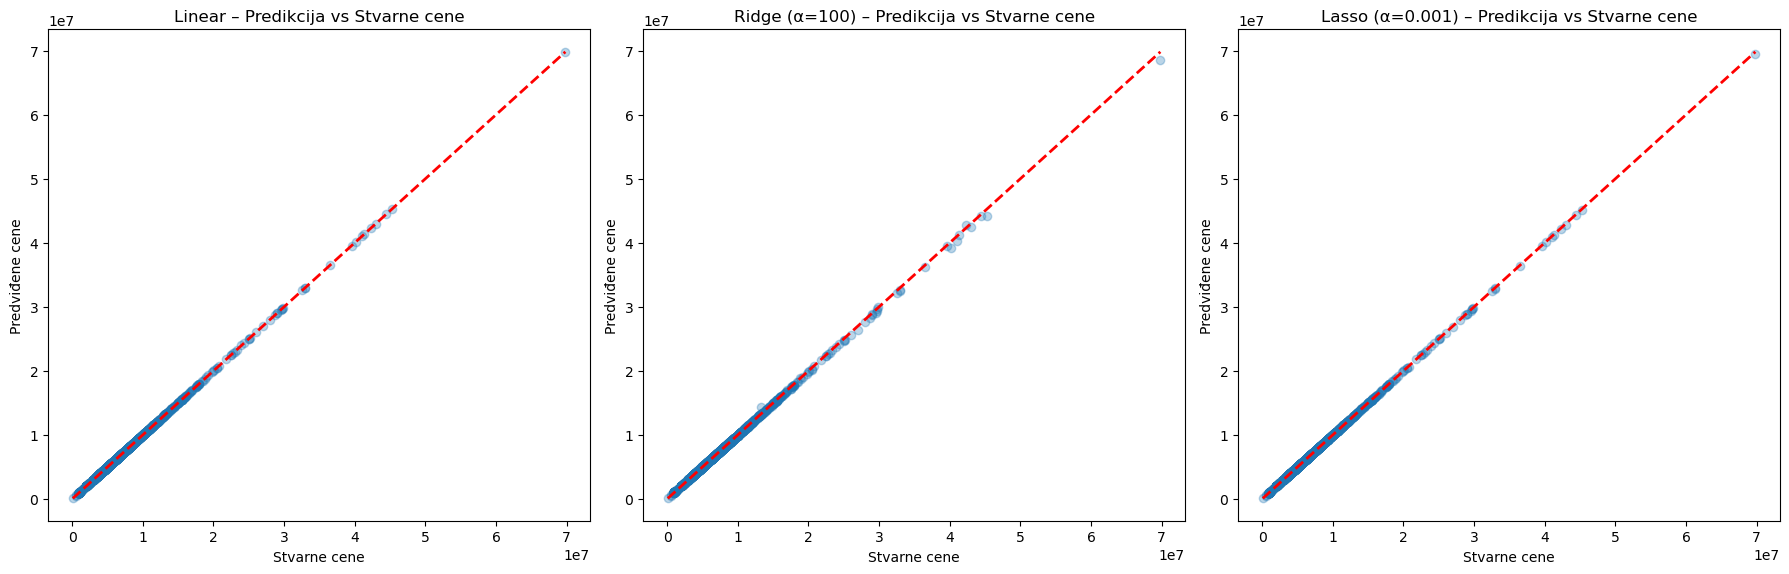

In [295]:
models = {
    "Linear": LinearRegression(),
    "Ridge (α=100)": Ridge(alpha=100, random_state=42),
    "Lasso (α=0.001)": Lasso(alpha=0.001, random_state=42, max_iter=10000)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_pred = unlog(y_pred)
    y_true = unlog(y_test)

    # scatter
    ax.scatter(y_true, y_pred, alpha=0.3)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
            "r--", lw=2)
    ax.set_title(f"{name} – Predikcija vs Stvarne cene")
    ax.set_xlabel("Stvarne cene")
    ax.set_ylabel("Predviđene cene")

plt.tight_layout()
plt.show()


R² je negativan – jer model u proseku promašuje gore nego što bi prosek pogodio.

RMSLE izgleda bolje – jer RMSLE ublažava uticaj outliera (log transformacija).

Graf pokazuje da model radi za većinu tipičnih primera, ali outlieri ga razbijaju.

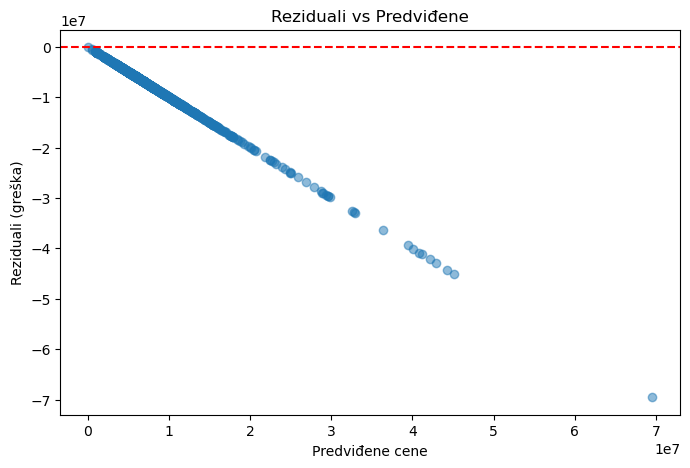

In [297]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predviđene cene")
plt.ylabel("Reziduali (greška)")
plt.title("Reziduali vs Predviđene")
plt.show()


Reziduali vs Predviđene

Idealno: tačke treba da budu nasumično raspoređene oko crvene linije (0).

Kod tebe: vidimo jak bias i outliere → model sistematski promašuje i podcenjuje ili precenjuje cene. To je znak da linearni model nije dovoljno fleksibilan.

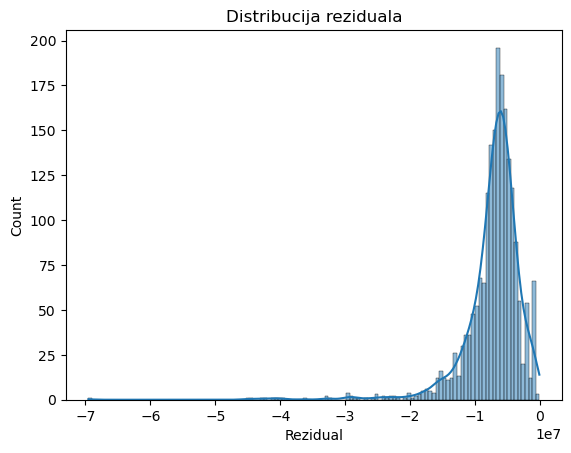

In [299]:
sns.histplot(residuals, kde=True)
plt.xlabel("Rezidual")
plt.title("Distribucija reziduala")
plt.show()


Idealno: simetrična i zvonasta (oko 0).

Kod tebe: jako leva asimetrija (dosta negativnih grešaka). To znači da ima puno slučajeva gde model jako podcenjuje cenu.

Ovo ti lepo objašnjava zašto je R² negativan – model je gori od naivnog predviđanja prosečne vrednosti.

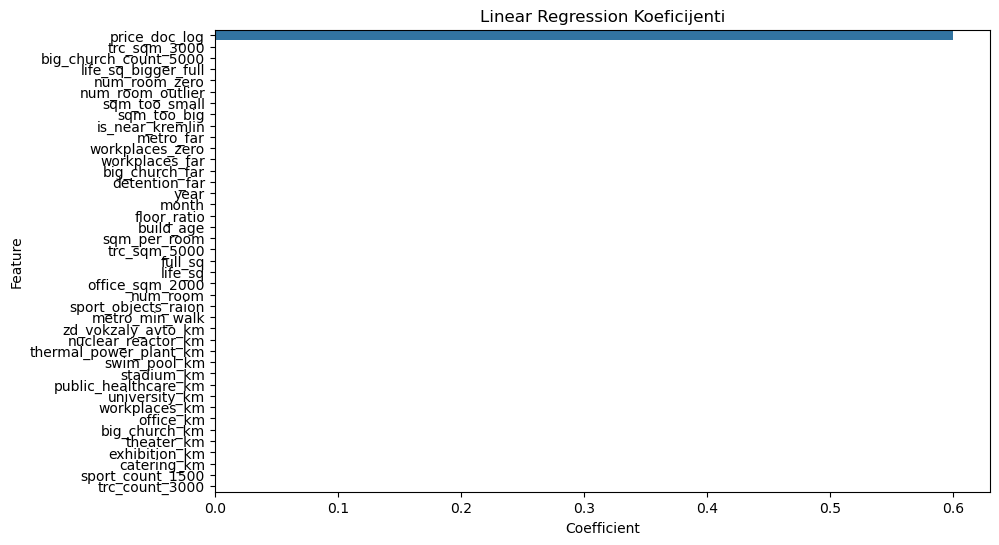

In [301]:
coefs = pipeline.named_steps["model"].coef_
features = pipeline.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({"Feature": features, "Coefficient": coefs})
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Linear Regression Koeficijenti")
plt.show()

Koeficijenti linearne regresije

Daje interpretabilnost: npr. full_sq, num_room, life_sq pozitivno utiču, dok udaljenost od nuclear_reactor_km, zd_vokzaly_avto_km negativno utiče.

Ovo je korisno za razumevanje šta model gleda, ali ne znači da daje dobre predikcije.

In [328]:
num_preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

pipeline = Pipeline(steps=[
    ("preprocessor", num_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# param grid za RandomForest
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring=rmsle_scorer,
    n_jobs=-1,
    verbose=2
)

# Fit
grid.fit(X_train, y_train)

print("Najbolji parametri:", grid.best_params_)
print("Najbolji score (RMSLE):", grid.best_score_)

# Finalna evaluacija na test setu
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

print("Evaluacija na test setu:")
evaluate_regression(y_test_unlog, y_pred)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Najbolji parametri: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Najbolji score (RMSLE): -0.029509154931596043
Evaluacija na test setu:
MSE:  9280032075166.867
RMSE:  3046314.506935695
MAE:  1746591.0974404141
R²:  0.5940116797990738
RMSLE:  0.47231333578510476


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


{'MSE': 9280032075166.867,
 'RMSE': 3046314.506935695,
 'MAE': 1746591.0974404141,
 'R²': 0.5940116797990738,
 'RMSLE': 0.47231333578510476}

In [330]:
pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),  # isti preprocesor koji si već definisao
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Param distribucije (šire od grid-a)
param_dist = {
    "model__n_estimators": randint(100, 1000),        # broj stabala
    "model__max_depth": [10, 20, 30, None],           # dubina stabala
    "model__min_samples_split": randint(2, 20),       # minimalni split
    "model__min_samples_leaf": randint(1, 10),        # minimalni list
    "model__max_features": ["sqrt", "log2", None]     # broj feature-a po splitu
}

# RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,              # koliko kombinacija da proba
    cv=3,                   # 3-fold cross validation
    scoring=rmsle_scorer,   # custom RMSLE scorer
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit
rand_search.fit(X_train, y_train)

print("Najbolji parametri:", rand_search.best_params_)
print("Najbolji score (RMSLE):", rand_search.best_score_)

# Finalna evaluacija na test setu
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)

y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

print("Evaluacija na test setu:")
evaluate_regression(y_test_unlog, y_pred)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najbolji parametri: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 6, 'model__n_estimators': 506}
Najbolji score (RMSLE): -0.029419585118331135
Evaluacija na test setu:
MSE:  9440846550003.924
RMSE:  3072596.0603378904
MAE:  1753827.596471535
R²:  0.5869762732429042
RMSLE:  0.4729097128764941


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


{'MSE': 9440846550003.924,
 'RMSE': 3072596.0603378904,
 'MAE': 1753827.596471535,
 'R²': 0.5869762732429042,
 'RMSLE': 0.4729097128764941}

In [331]:
print(len(rand_search.best_estimator_.named_steps["model"].feature_importances_))

39


In [332]:
len(X_train.columns)

56

39 39 True


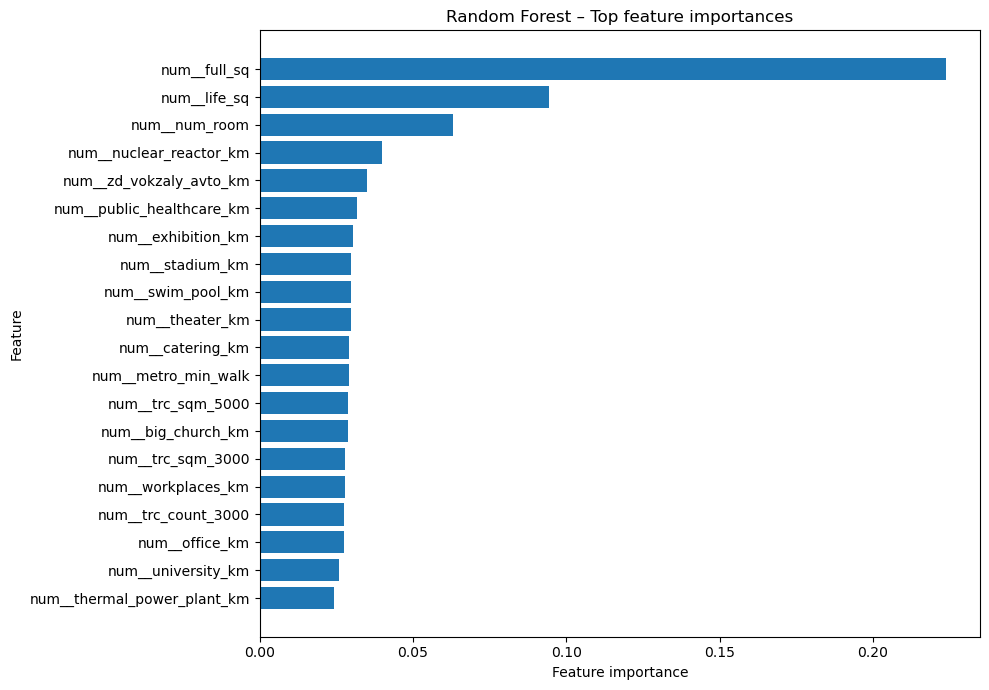

In [333]:
best_pipe = rand_search.best_estimator_
preproc   = best_pipe.named_steps["preprocessor"]
rf        = best_pipe.named_steps["model"]

names = preproc.get_feature_names_out()
imps  = rf.feature_importances_

# sanity check
print(len(names), len(imps), np.isclose(imps.sum(), 1.0))

# TOP N tabela i plot
feat_df = (pd.DataFrame({"Feature": names, "Importance": imps})
           .sort_values("Importance", ascending=False))

TOPN = 20
plt.figure(figsize=(10,7))
plt.barh(feat_df["Feature"].head(TOPN)[::-1], feat_df["Importance"].head(TOPN)[::-1])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest – Top feature importances")
plt.tight_layout()
plt.show()



C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


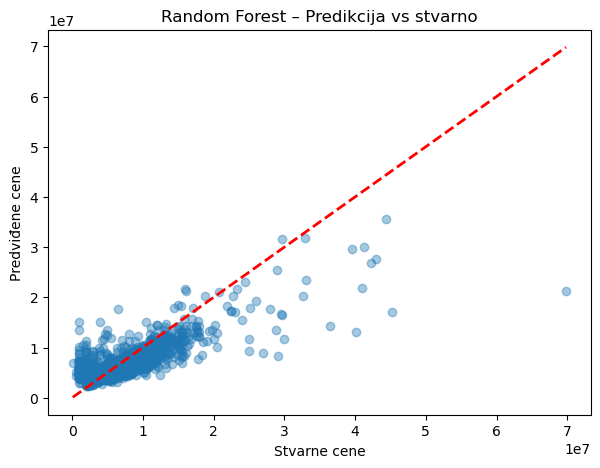

In [334]:
pipe_best = rand_search.best_estimator_

y_pred_log = pipe_best.predict(X_test)
y_pred = unlog(y_pred_log)
y_true = unlog(y_test)

import numpy as np, matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(y_true, y_pred, alpha=0.4)
m = [np.min([y_true, y_pred]), np.max([y_true, y_pred])]
plt.plot(m, m, "r--", lw=2)        # idealna linija y=x
plt.xlabel("Stvarne cene"); plt.ylabel("Predviđene cene")
plt.title("Random Forest – Predikcija vs stvarno")
plt.show()


Predikcija vs stvarne cene (ŷ naspram y)

Isprekidana linija je savršena pogodivost (ŷ = y).

Tačke su uglavnom ispod linije za skupe stanove → model sistematski potcenjuje visoke cene.

U nižem cenovnom rangu rasipanje je manje, pa tu pogadja bolje.
    
Bias: downward bias na „skupom repu“. Pomaže log-target, robustniji modeli i bolja obrada outliera.

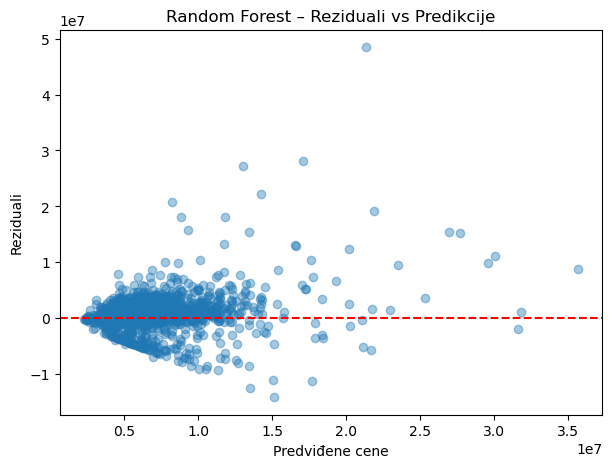

In [336]:
resid = y_true - y_pred
plt.figure(figsize=(7,5))
plt.scatter(y_pred, resid, alpha=0.4)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predviđene cene"); plt.ylabel("Reziduali")
plt.title("Random Forest – Reziduali vs Predikcije")
plt.show()


Reziduali vs predikcije (r = y − ŷ naspram ŷ)

Oblik „levka“: varijansa reziduala raste sa predikcijom (heteroskedastičnost).

Mnogi pozitivni reziduali pri većim ŷ → potcenjivanje kada su cene visoke.
    
Dodatna obrada outliera, još feature-a koji objašnjavaju luksuz/centar, i/ili modeli koji bolje hvataju nelinearnosti.

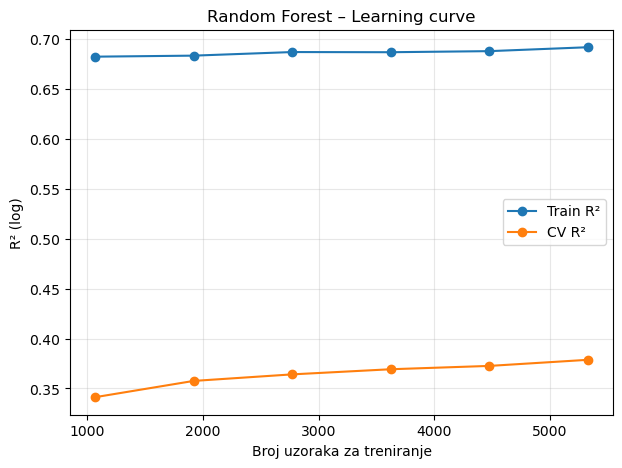

In [355]:
train_sizes, train_scores, val_scores = learning_curve(
    pipe_best, X_train, y_train,
    cv=3, scoring="r2",  # R² u log skali
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1, shuffle=True, random_state=42
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train R²")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV R²")
plt.xlabel("Broj uzoraka za treniranje"); plt.ylabel("R² (log)")
plt.title("Random Forest – Learning curve")
plt.legend(); plt.grid(alpha=0.3); plt.show()

Learning curve (R² na log-targetu)

Train R² visoko (0.74) i stabilno; CV R² znatno niži (0.40) ali raste sa više uzoraka.

Jasna varijanca (overfitting): model uči, ali bi mu koristilo još podataka i/ili jača regularizacija.
    
Probaj veći min_samples_leaf / min_samples_split, limit depth, više podataka ili ensembling (GBM/LightGBM/CatBoost).

In [357]:
pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),
    ("model", RandomForestRegressor(
        random_state=42, 
        n_jobs=-1,
        max_depth=6,
        max_features='sqrt',
        min_samples_leaf=10,
        min_samples_split=5
    ))
])

pipe.fit(X_train,y_train)


r2_train = r2_score(y_train, pipe.predict(X_train))
r2_test  = r2_score(y_test, pipe.predict(X_test))

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")


Train R²: 0.3824
Test  R²: 0.3426


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


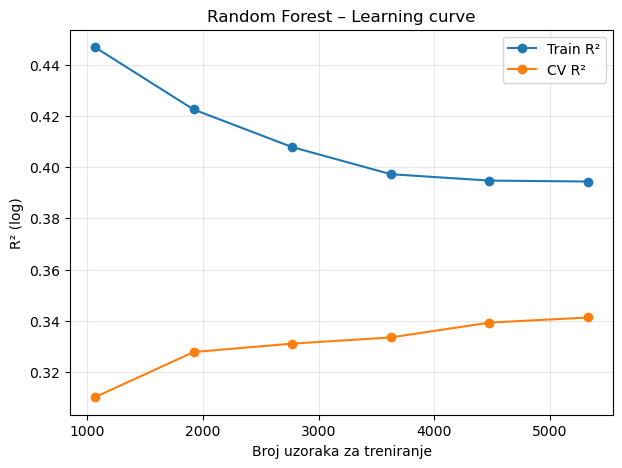

In [359]:
train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_train, y_train,
    cv=3, scoring="r2",  # R² u log skali
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1, shuffle=True, random_state=42
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train R²")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV R²")
plt.xlabel("Broj uzoraka za treniranje"); plt.ylabel("R² (log)")
plt.title("Random Forest – Learning curve")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [361]:
pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),  # tvoj ColumnTransformer
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",  # za regresiju
        tree_method="hist",            # brža obuka
        random_state=42,
        n_jobs=-1
    ))
])


param_dist = {
    "model__n_estimators": [300, 600, 900],
    "model__max_depth": [3, 6, 9, 12],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.3],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}



rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring=rmsle_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)


rand_search.fit(X_train, y_train)

print("Najbolji parametri:", rand_search.best_params_)
print("Najbolji RMSLE score:", rand_search.best_score_)

# Test set evaluacija
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)

y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred)  # Tvoja funkcija

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najbolji parametri: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Najbolji RMSLE score: -0.0294196193520523
MSE:  7995001509996.838
RMSE:  2827543.370135432
MAE:  1764686.8509759754
R²:  0.6502299553755453
RMSLE:  0.47139650412500617


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


{'MSE': 7995001509996.838,
 'RMSE': 2827543.370135432,
 'MAE': 1764686.8509759754,
 'R²': 0.6502299553755453,
 'RMSLE': 0.47139650412500617}

In [422]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),  # mora imati samo numeričke/obradjene kolone
    ("model", xgb.XGBRegressor(
    objective="reg:squarederror",  # regresija
    tree_method="hist",            # brže treniranje
    random_state=42,
    n_jobs=-1,
    # tvoji pronađeni hiperparametri:
    subsample=0.8,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=1.0
    ))
])

# Cross-val predikcije (log space)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = cross_val_predict(pipe, X_train, y_train, cv=cv, n_jobs=-1)

In [426]:
evaluate_regression(y_train, oof_preds)

MSE:  0.22354247843114197
RMSE:  0.4728027902108256
MAE:  0.2871791700249696
R²:  0.38124023779114125
RMSLE:  0.029381690409125992


{'MSE': 0.22354247843114197,
 'RMSE': 0.4728027902108256,
 'MAE': 0.2871791700249696,
 'R²': 0.38124023779114125,
 'RMSLE': 0.029381690409125992}

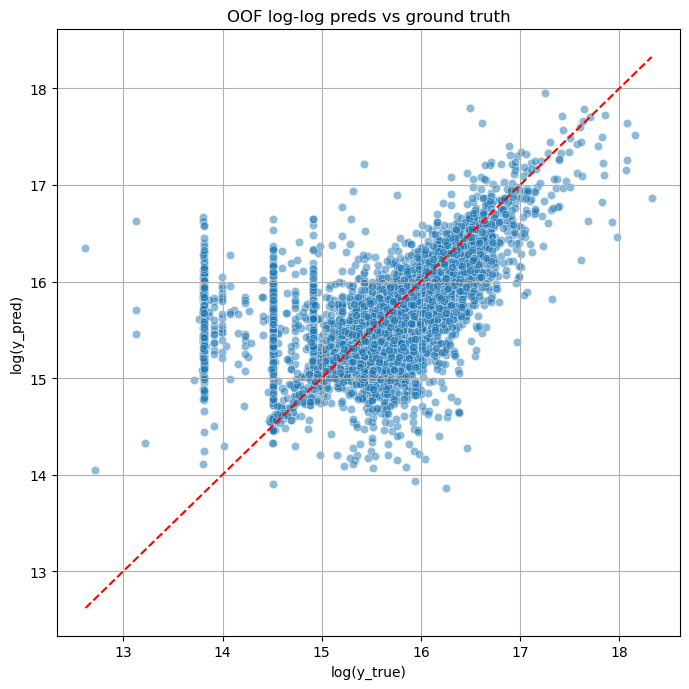

In [365]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_train, y=oof_preds, alpha=0.5)
plt.xlabel("log(y_true)")
plt.ylabel("log(y_pred)")
plt.title("OOF log-log preds vs ground truth")
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         linestyle='--', color='red')  # idealna linija
plt.grid()
plt.tight_layout()
plt.show()


In [367]:
param_dist = {
    "model__n_estimators": [300, 600, 900],
    "model__max_depth": [3, 6, 9, 12],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.3],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}

rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring=rmsle_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_train, y_train)
best_model = rand_search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [438]:
y_pred = best_model.predict(X_test)

# Unloguj rezultat
y_pred = np.expm1(y_pred)
y_true = np.expm1(y_test)

# Evaluacija
print("RMSLE:", rmsle(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2:", r2_score(y_true, y_pred))


RMSLE: 0.47139650412500617
RMSE: 2827543.370135432
R2: 0.6502299553755453


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


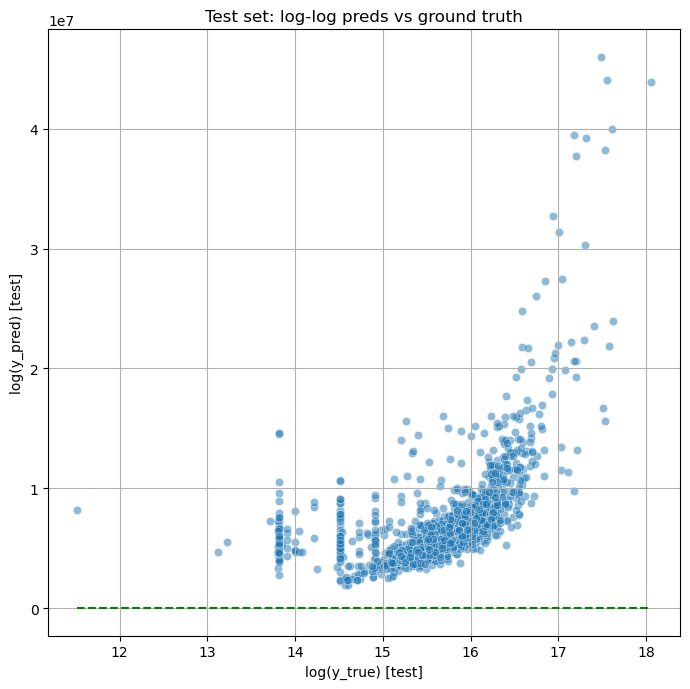

In [369]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("log(y_true) [test]")
plt.ylabel("log(y_pred) [test]")
plt.title("Test set: log-log preds vs ground truth")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='green')  # idealna linija
plt.grid()
plt.tight_layout()
plt.show()


In [370]:
print(y_pred)

[5791032.  3336427.5 5622321.5 ... 6726234.  5491164.  2673574.5]


In [371]:
base_estimators = [
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )),
    ("lgb", LGBMRegressor(
        objective="regression",
        boosting_type="gbdt",
        n_jobs=-1,
        random_state=42
    )),
    ("ridge", RidgeCV(alphas=(0.1, 1.0, 10.0)))
]
final_estimator = RidgeCV(alphas=(0.1, 1.0, 10.0))


In [372]:
df["price_doc_log"].head()

8538     16.325110
21619    15.607270
27749    16.993564
6414     13.997833
19470    15.654459
Name: price_doc_log, dtype: float64

In [373]:
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator,
    passthrough=True,  # ako hoćeš da svi prediktori dobiju originalne feature-e
    n_jobs=-1,
    cv=5
)

preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])


In [374]:
# Pretvori sve u numpy ako već nisu
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

# Maskiraj gde nije NaN
mask = (~np.isnan(y_test_arr)) & (~np.isnan(y_pred_arr))

# Ocene
mse = mean_squared_error(y_test_arr[mask], y_pred_arr[mask])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_arr[mask], y_pred_arr[mask])
r2 = r2_score(y_test_arr[mask], y_pred_arr[mask])

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")


RMSE: 7701377.76
MAE: 6716838.66
R²: -162724748174591.2188


In [375]:
print(y_test.isna().sum().sum())

0


In [392]:
y_pred

array([5791032. , 3336427.5, 5622321.5, ..., 6726234. , 5491164. ,
       2673574.5], dtype=float32)

In [394]:
evaluate_regression(unlog(y_test), y_pred)

MSE:  7995001509996.838
RMSE:  2827543.370135432
MAE:  1764686.8509759754
R²:  0.6502299553755453
RMSLE:  0.47139650412500617


{'MSE': 7995001509996.838,
 'RMSE': 2827543.370135432,
 'MAE': 1764686.8509759754,
 'R²': 0.6502299553755453,
 'RMSLE': 0.47139650412500617}

In [442]:
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=RidgeCV()
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

model_pipeline.fit(X, y)
 # trenirani meta-model

ValueError: Found unknown categories ['no data'] in column 0 during fit

In [410]:
meta = model_pipeline.named_steps["stacking"].final_estimator_
print(meta)


RidgeCV()


In [412]:
print(model_pipeline.named_steps["stacking"].final_estimator_.coef_)


[0.04120728 0.54716825 0.41030822]


In [472]:


X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

price = unlog(y_train)     
w = 1 / np.sqrt(price)

num_preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),  # mora imati samo numeričke/obradjene kolone
    ("model", xgb.XGBRegressor(
    objective="reg:squarederror",  # regresija
    tree_method="hist",            # brže treniranje
    random_state=42,
    n_jobs=-1,
    # tvoji pronađeni hiperparametri:
    subsample=0.8,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=1.0
    ))
])

pipe.fit(
    X_train, 
    y_train,
    model__sample_weight=w
)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('preprocess', ...), ('quantile', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nominal', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3


In [474]:
evaluate_regression(unlog(y_test), y_pred)

MSE:  7995001509996.838
RMSE:  2827543.370135432
MAE:  1764686.8509759754
R²:  0.6502299553755453
RMSLE:  0.47139650412500617


{'MSE': 7995001509996.838,
 'RMSE': 2827543.370135432,
 'MAE': 1764686.8509759754,
 'R²': 0.6502299553755453,
 'RMSLE': 0.47139650412500617}

In [ ]:
df_hybrid4 = df

In [492]:
# === Target 1: log(price_doc) ===
df1 = df_hybrid3.copy()
df1 = df1[df1["price_doc"].notna() & df1["full_sq"].notna()]

df1["y_log_price"] = np.log(df1["price_doc"])

X1 = df1.drop(columns=["price_doc", "y_log_price"])
y1 = df1["y_log_price"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

pipe.fit(X1_train, y1_train)
y1_pred = pipe.predict(X1_test)

rmsle_price = np.sqrt(mean_squared_log_error(np.exp(y1_test), np.exp(y1_pred)))
print("RMSLE (log price_doc):", rmsle_price)


# === Target 2: log(price_per_m2) ===
df2 = df_hybrid3.copy()
df2 = df2[df2["price_doc"].notna() & df2["full_sq"].notna() & (df2["full_sq"] > 0)]

df2["price_per_m2"] = df2["price_doc"] / df2["full_sq"]
df2["y_log_price_m2"] = np.log(df2["price_per_m2"])

X2 = df2.drop(columns=["price_doc", "price_per_m2", "y_log_price_m2"])
y2 = df2["y_log_price_m2"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

pipe.fit(X2_train, y2_train)
y2_pred = pipe.predict(X2_test)

C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


RMSLE (log price_doc): 0.4713965399736251


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [508]:
evaluate_regression(unlog(y1_test),unlog(y1_pred))

MSE:  7995011316667.251
RMSE:  2827545.1042675255
MAE:  1764689.0255255252
R²:  0.6502295263475407
RMSLE:  0.47139674208510995


{'MSE': 7995011316667.251,
 'RMSE': 2827545.1042675255,
 'MAE': 1764689.0255255252,
 'R²': 0.6502295263475407,
 'RMSLE': 0.47139674208510995}

In [510]:
evaluate_regression(unlog(y2_test),unlog(y2_pred))

MSE:  2077266000.3762703
RMSE:  45577.03369435389
MAE:  32010.412897974544
R²:  0.31366497149432737
RMSLE:  0.46954304688065934


{'MSE': 2077266000.3762703,
 'RMSE': 45577.03369435389,
 'MAE': 32010.412897974544,
 'R²': 0.31366497149432737,
 'RMSLE': 0.46954304688065934}